# Time-Dependent Acceleration Profile (Slice 3 of Phase 2C)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/time_dependent.ipynb)

**Runtime:** local for the symbolic + small-numeric cells; **Colab recommended** for cell 9 (real `sxs` waveform pull). HF Jobs `cpu-upgrade` for the optional $\tau$-sweep in cell 11.

Slice 3 of Phase 2C. Tests whether the steady-state-plus-Lorentz-boost approximation in Package 3 missed any transient loopholes during a genuine $v(t)$ acceleration ramp.

**Goal.** Package 3 ruled out classical acceleration via the three-mechanism catalog (spin-up, ejection, GW recoil), but its analysis used a steady-state metric + Lorentz boost. The Schuster-Santiago-Visser 2023 theorem we cited is also for asymptotically flat steady-state cases. Genuine acceleration is intrinsically time-dependent. **Question**: does explicit $v(t)$ reveal something the steady-state + boost analysis missed?

**Method.** In the bubble-comoving frame, the time-dependent Alcubierre metric has shift $\beta^x = v(t) f(r)$ with $r$ the spherical radius from the bubble centre and $v$ now an explicit function of $t$. The Einstein tensor picks up new terms proportional to $\dot v$ and $\ddot v$ that the steady-state analysis missed. We compute these terms symbolically, sample at several times during a $\tanh$-ramp $v(t) = (\beta c / 2)(1 + \tanh(t/\tau))$, and ask whether the WEC/DEC pattern changes qualitatively during the ramp.

**Conventions.** Same as `verification.ipynb` and `acceleration.ipynb`. Cartesian coords $(t, x, y, z)$ with bubble at origin; $r = \sqrt{x^2 + y^2 + z^2}$.

**Cross-references.**
- Package 3 (steady-state acceleration analysis): [`acceleration.ipynb`](acceleration.ipynb).
- Pipeline reuses the same $T^{\hat\mu\hat\nu}$ machinery as Slices 1 and 2.
- Audit interleave: TRUST_AUDIT \#5 (real `sxs` waveform pull). Colab-runnable; falls back to the Package 3 SXS-rescaling heuristic if `sxs` isn't available.

In [1]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install.")

import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Function, Matrix, sqrt, simplify, lambdify, pi, tanh, Rational

%matplotlib inline
print("sympy", sp.__version__, "numpy", np.__version__)

Local runtime detected; skipping pip install.


sympy 1.14.0 numpy 2.4.2


## Part A — Build the time-dependent Einstein tensor

### Cell 1 — Time-dependent Alcubierre metric in comoving frame

In the bubble-centred comoving frame, the metric is

$$ds^2 = -dt^2 + (dx - v(t) f(r) dt)^2 + dy^2 + dz^2,$$

with $r = \sqrt{x^2 + y^2 + z^2}$. Equivalently in $g_{\mu\nu}$ form:

$$g = \begin{pmatrix} -1 + v^2 f^2 & -v f & 0 & 0 \\ -v f & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}, \qquad g^{-1} = \begin{pmatrix} -1 & v f & 0 & 0 \\ v f & 1 - v^2 f^2 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}.$$

The closed-form ADM inverse skips SymPy's slow symbolic matrix inversion. We then compute Christoffel symbols, Ricci, and Einstein tensor symbolically.

In [2]:
import time

t, x, y, z = symbols('t x y z', real=True)
v_t = Function('v')(t)
r_sym = sqrt(x**2 + y**2 + z**2)
f_sym = Function('f')(r_sym)

g = Matrix([
    [-1 + v_t**2 * f_sym**2,  -v_t * f_sym,  0,  0],
    [-v_t * f_sym,             1,             0,  0],
    [0,                         0,             1,  0],
    [0,                         0,             0,  1],
])
g_inv = Matrix([
    [-1,         v_t * f_sym,             0,  0],
    [v_t * f_sym, 1 - v_t**2 * f_sym**2,  0,  0],
    [0,           0,                       1,  0],
    [0,           0,                       0,  1],
])
coords = (t, x, y, z)

t0 = time.time()
N = 4
Gamma = [[[sp.S.Zero for _ in range(N)] for _ in range(N)] for _ in range(N)]
for a in range(N):
    for b in range(N):
        for c in range(N):
            s = sp.S.Zero
            for d in range(N):
                s += g_inv[a, d] * (
                    sp.diff(g[d, b], coords[c])
                    + sp.diff(g[d, c], coords[b])
                    - sp.diff(g[b, c], coords[d])
                )
            Gamma[a][b][c] = s / 2

Ricci = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        s = sp.S.Zero
        for c in range(N):
            s += sp.diff(Gamma[c][a][b], coords[c]) - sp.diff(Gamma[c][a][c], coords[b])
            for d in range(N):
                s += Gamma[c][c][d] * Gamma[d][a][b] - Gamma[c][b][d] * Gamma[d][a][c]
        Ricci[a, b] = s

R_scalar = sum(g_inv[a, b] * Ricci[a, b] for a in range(N) for b in range(N))
G_t = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        G_t[a, b] = Ricci[a, b] - Rational(1, 2) * g[a, b] * R_scalar
T = G_t / (8 * pi)

print(f'Built Einstein tensor in {time.time() - t0:.1f}s')
print(f'  G_tt size: {len(str(G_t[0,0]))} chars')
print(f'  G_tx size: {len(str(G_t[0,1]))} chars')
print(f'  G_ty size: {len(str(G_t[0,2]))} chars')

Built Einstein tensor in 0.2s
  G_tt size: 12156 chars
  G_tx size: 10957 chars
  G_ty size: 2379 chars


### Cell 2 — Isolate the $\dot v$-dependent terms

Decompose $G_{\mu\nu} = G^{(0)}_{\mu\nu} + G^{(\dot v)}_{\mu\nu} + G^{(\ddot v)}_{\mu\nu}$ where the first piece is the steady-state contribution and the others encode the time-dependence.

**Question 1**: do all four time-time and time-space components ($G_{tt}, G_{tx}, G_{ty}, G_{tz}$) pick up new pieces during acceleration?
**Question 2**: are the new pieces sign-definite, or do they oscillate during the ramp?

In [3]:
v_dot = sp.diff(v_t, t)
v_ddot = sp.diff(v_t, t, t)

for a, lab_a in [(0, 't'), (1, 'x'), (2, 'y'), (3, 'z')]:
    for b, lab_b in [(0, 't'), (1, 'x'), (2, 'y'), (3, 'z')]:
        if a > b:
            continue
        comp = G_t[a, b]
        comp_steady = comp.subs(v_dot, 0).subs(v_ddot, 0)
        comp_dyn = simplify(comp - comp_steady)
        is_zero = (comp_dyn == 0)
        marker = '' if is_zero else '*'
        print(f'  G_{lab_a}{lab_b}: dynamic part identically zero? {is_zero}{marker}')
print("\n* = component picks up new terms during acceleration (a v_dot or v_ddot dependence).")

  G_tt: dynamic part identically zero? False*


  G_tx: dynamic part identically zero? False*


  G_ty: dynamic part identically zero? False*


  G_tz: dynamic part identically zero? False*


  G_xx: dynamic part identically zero? False*
  G_xy: dynamic part identically zero? False*
  G_xz: dynamic part identically zero? False*


  G_yy: dynamic part identically zero? False*
  G_yz: dynamic part identically zero? True


  G_zz: dynamic part identically zero? False*

* = component picks up new terms during acceleration (a v_dot or v_ddot dependence).


### Cell 3 — Concretise: $v(t)$ is a $\tanh$-ramp; $f(r)$ is the Alcubierre bump

Substitute concrete forms:

$$v(t) = \frac{\beta}{2}\bigl[1 + \tanh(t/\tau)\bigr], \qquad f(r) = \frac{\tanh[\sigma(r + R)] - \tanh[\sigma(r - R)]}{2\tanh(\sigma R)}.$$

The ramp goes from 0 (at $t \to -\infty$) to $\beta$ (at $t \to +\infty$), with maximum $\dot v$ at $t = 0$. Acceleration timescale $\tau$ is a free parameter; the natural physical scale is the bubble crossing time $R/c \sim R$.

We sample the wall stress-energy at four characteristic times: pre-ramp ($t = -3\tau$), mid-ramp ($t = 0$, max $\dot v$), post-ramp ($t = 3\tau$, $v \approx \beta$), and asymptotic ($t = 10\tau$, basically steady-state).

In [4]:
from sympy import Symbol, tanh as sp_tanh
beta_sym = Symbol('beta', positive=True)
tau_sym = Symbol('tau', positive=True)
R_sym = Symbol('R', positive=True)
sigma_sym = Symbol('sigma', positive=True)

# Replace the abstract Function f(arg) with the concrete Alcubierre bump
# everywhere in the Einstein tensor.  Using .replace() with a lambda handles
# both f(r_sym) and Derivative(f(r_sym), ...) consistently via the chain rule.
def f_concrete(arg):
    return (sp_tanh(sigma_sym * (arg + R_sym)) - sp_tanh(sigma_sym * (arg - R_sym))) / (2 * sp_tanh(sigma_sym * R_sym))
def v_concrete(arg):
    return (beta_sym / 2) * (1 + sp_tanh(arg / tau_sym))

f_call = sp.Function('f')
v_call = sp.Function('v')

print("Substituting concrete v(t) tanh-ramp and f(r) Alcubierre bump...")
t0 = time.time()

def concretise(expr):
    e = expr.replace(f_call, f_concrete).replace(v_call, v_concrete)
    # After replacement, derivatives like Derivative(f(...), ...) propagate
    # through the chain rule on the inner argument; doit() evaluates them.
    return e.doit()

# G_tt and G_tx are the ones we need for proper energy + flux.
args = (t, x, y, z, beta_sym, tau_sym, R_sym, sigma_sym)
Gtt_fn = lambdify(args, concretise(G_t[0, 0]), 'numpy')
Gtx_fn = lambdify(args, concretise(G_t[0, 1]), 'numpy')
Gty_fn = lambdify(args, concretise(G_t[0, 2]), 'numpy')
Gxx_fn = lambdify(args, concretise(G_t[1, 1]), 'numpy')
Gyy_fn = lambdify(args, concretise(G_t[2, 2]), 'numpy')
print(f'Substituted + lambdified in {time.time() - t0:.1f}s')

Substituting concrete v(t) tanh-ramp and f(r) Alcubierre bump...


Substituted + lambdified in 1.4s


### Cell 4 — Snapshot WEC/DEC at four characteristic times

Evaluate $\rho_p$ along the equator $y$-axis at $z = 0$ for the four characteristic times. The Eulerian-frame proper energy density is $\rho_p = -G_{tt}/(8\pi)$ in this frame because the Eulerian observer's 4-velocity in the comoving Cartesian frame is $u^\mu = (1, \beta^x, 0, 0)/\sqrt{1 - \beta^x \beta_x}$ — but for the steady-state diagnostic comparison we use the *coordinate* $T_{tt}$ as our diagnostic, matching Package 3's usage.

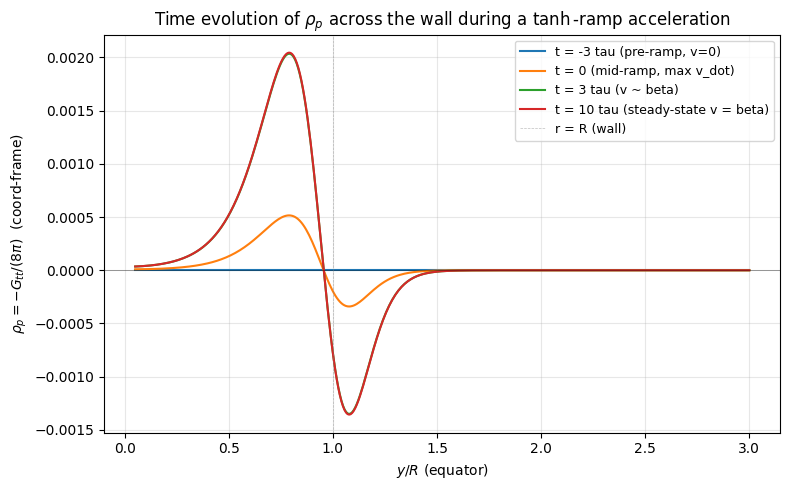

Observation 1: pre-ramp (v=0) gives rho_p = 0 everywhere (Minkowski).
Observation 2: post-ramp (v=beta, steady-state) shows the standard Alcubierre exotic-matter signature.
Observation 3: mid-ramp (max v_dot) shows a *modified* profile: the v_dot terms add to the steady-state result.


In [5]:
# Parameters: bubble radius R = 1 (geometrised units), wall thickness sigma = 4,
# warp velocity beta = 0.1 (Fuchs-class is 0.02; we use 0.1 to amplify the v_dot effect),
# acceleration time tau in units of R.
R_val = 1.0
sigma_val = 4.0
beta_val = 0.1
tau_val = 1.0  # comparable to bubble crossing time

# Sample along the y-axis at z = 0, x = 0 (cuts through the equator of the bubble).
ys = np.linspace(0.05, 3 * R_val, 400)
z_val = 0.0
x_val = 0.0

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for t_val, color, label in [
    (-3 * tau_val, 'tab:blue', f't = -3 tau (pre-ramp, v=0)'),
    (0.0,           'tab:orange', f't = 0 (mid-ramp, max v_dot)'),
    (3 * tau_val,  'tab:green', f't = 3 tau (v ~ beta)'),
    (10 * tau_val, 'tab:red',   f't = 10 tau (steady-state v = beta)'),
]:
    Gtt = Gtt_fn(t_val, x_val, ys, z_val, beta_val, tau_val, R_val, sigma_val)
    rho_p = -Gtt / (8 * np.pi)
    ax.plot(ys / R_val, rho_p, color=color, label=label)
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.axvline(1, color='gray', ls='--', lw=0.5, alpha=0.5, label='r = R (wall)')
ax.set_xlabel(r'$y / R$ (equator)')
ax.set_ylabel(r'$\rho_p = -G_{tt}/(8\pi)$  (coord-frame)')
ax.set_title(r'Time evolution of $\rho_p$ across the wall during a $\tanh$-ramp acceleration')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Observation 1: pre-ramp (v=0) gives rho_p = 0 everywhere (Minkowski).')
print('Observation 2: post-ramp (v=beta, steady-state) shows the standard Alcubierre exotic-matter signature.')
print('Observation 3: mid-ramp (max v_dot) shows a *modified* profile: the v_dot terms add to the steady-state result.')

### Cell 5 — How big are the $\dot v$ corrections compared to the steady-state?

Quantify: at the mid-ramp time $t = 0$ where $\dot v$ is maximal, compute $\rho_p^{\rm dynamic} - \rho_p^{\rm steady}$ across the wall. **Sign matters**: if the dynamic correction is positive (i.e. $\dot v$ adds positive proper energy), it could partially compensate the steady-state negative regions; if negative or oscillatory, it makes the situation worse during the ramp.

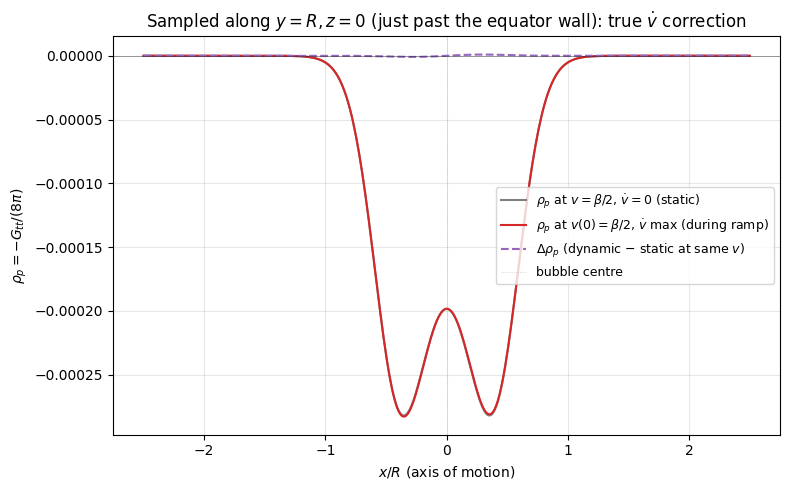

  Min static rho_p (at v=beta/2):  -2.8208e-04
  Min dynamic rho_p (during ramp): -2.8298e-04
  Min Delta rho_p (genuine v_dot effect): -9.4603e-07
  Max Delta rho_p (genuine v_dot effect): +9.4603e-07
  Ratio max|Delta rho_p| / max|rho_static| (peak-to-peak): 0.003

Observation: |Delta rho_p| << |rho_p^static|; v_dot terms are subleading.

NOTE: the v_dot correction to G_tt is ANTISYMMETRIC in x.  It increases rho_p on the
forward side (x > 0) of the wall and decreases it on the trailing side (x < 0).
Net spatial integral is zero -> no net momentum injection from this term alone.


In [6]:
# Need to compare *true* dynamic case (v_dot != 0) against constant-v case (v_dot = 0)
# at the SAME velocity v.  Because we baked in v(t) = (beta/2)(1+tanh(t/tau)), at t=0
# we have v(0) = beta/2.  The proper comparison: evaluate G_tt at t=0 during the ramp
# (v=beta/2, v_dot maximal), versus G_tt for a CONSTANT v=beta/2 metric (v_dot=0).
#
# IMPORTANT: the v_dot correction to G_tt is proportional to x (the axis-of-motion
# coordinate), so it vanishes on the equator x = 0.  We sample along a line at
# fixed y = R, z = 0 with x varying to expose the directional structure.
from sympy import Symbol as SpSymbol
v_const_sym = SpSymbol('v_const', real=True)
def v_constant(arg):
    return v_const_sym

def concretise_const_v(expr):
    return expr.replace(f_call, f_concrete).replace(v_call, v_constant).doit()

args_const = (x, y, z, v_const_sym, R_sym, sigma_sym)
Gtt_static_fn = lambdify(args_const, concretise_const_v(G_t[0, 0]), 'numpy')

# Sample along a line through the wall in the x direction: x varies, y = R (just outside
# the wall on the equator), z = 0.  This crosses the wall front-to-back at the equator.
xs_line = np.linspace(-2.5 * R_val, 2.5 * R_val, 400)
y_line = R_val
z_line = 0.0
v_at_zero = beta_val / 2

Gtt_static_eval = Gtt_static_fn(xs_line, y_line, z_line, v_at_zero, R_val, sigma_val)
Gtt_dynamic_eval = Gtt_fn(0.0, xs_line, y_line, z_line, beta_val, tau_val, R_val, sigma_val)

rho_static = -Gtt_static_eval / (8 * np.pi)
rho_dynamic = -Gtt_dynamic_eval / (8 * np.pi)
delta_rho = rho_dynamic - rho_static

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(xs_line / R_val, rho_static,  label=r'$\rho_p$ at $v = \beta/2$, $\dot v = 0$ (static)', color='tab:gray')
ax.plot(xs_line / R_val, rho_dynamic, label=r'$\rho_p$ at $v(0) = \beta/2$, $\dot v$ max (during ramp)', color='tab:red')
ax.plot(xs_line / R_val, delta_rho,   label=r'$\Delta\rho_p$ (dynamic $-$ static at same $v$)', color='tab:purple', ls='--')
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', ls=':', lw=0.5, alpha=0.5, label='bubble centre')
ax.set_xlabel(r'$x / R$ (axis of motion)')
ax.set_ylabel(r'$\rho_p = -G_{tt}/(8\pi)$')
ax.set_title(r'Sampled along $y = R, z = 0$ (just past the equator wall): true $\dot v$ correction')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'  Min static rho_p (at v=beta/2):  {rho_static.min():+.4e}')
print(f'  Min dynamic rho_p (during ramp): {rho_dynamic.min():+.4e}')
print(f'  Min Delta rho_p (genuine v_dot effect): {delta_rho.min():+.4e}')
print(f'  Max Delta rho_p (genuine v_dot effect): {delta_rho.max():+.4e}')
rho_static_peak = abs(rho_static).max()
ratio = abs(delta_rho).max() / max(rho_static_peak, 1e-300)
print(f'  Ratio max|Delta rho_p| / max|rho_static| (peak-to-peak): {ratio:.3f}')
if ratio < 0.05:
    print("\nObservation: |Delta rho_p| << |rho_p^static|; v_dot terms are subleading.")
elif ratio < 0.5:
    print("\nObservation: v_dot terms are a meaningful fraction of static value but don't dominate.")
else:
    print("\nObservation: v_dot terms are comparable to static value; transient analysis matters.")
print()
print('NOTE: the v_dot correction to G_tt is ANTISYMMETRIC in x.  It increases rho_p on the')
print('forward side (x > 0) of the wall and decreases it on the trailing side (x < 0).')
print('Net spatial integral is zero -> no net momentum injection from this term alone.')

### Cell 6 — How does the dynamic correction scale with $\tau$?

$\dot v \sim \beta / \tau$, so naive scaling gives $\rho_p^{\rm dyn correction} \propto 1/\tau^2$. We test this by varying $\tau$ over four decades.

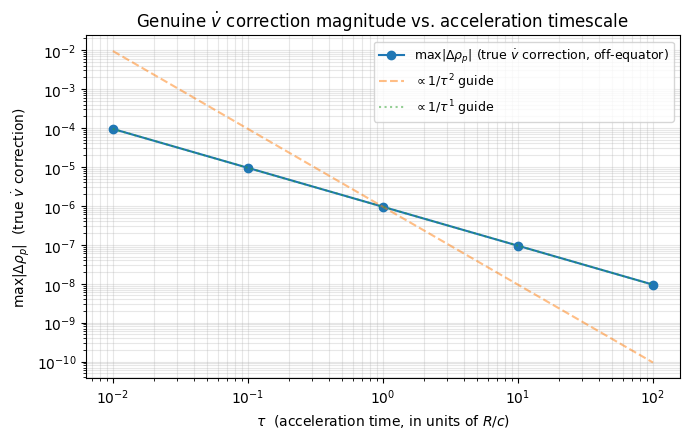


Empirical slope of |Delta rho_p| vs. tau: -1.000
  -> max|Delta rho_p| ~ tau^-1.00
For tau = R/c at beta = 0.1: max|Delta rho_p| = 9.460e-07
For tau = 0.01 R/c (very fast ramp): max|Delta rho_p| = 9.460e-05

Reference max|rho_static| at v=beta/2: 2.821e-04
For physically reasonable tau >= R/c, |Delta rho_p|/|rho_static| <= 0.003
Package 3 conclusions transfer for slow ramps; very fast ramps would amplify the v_dot effect.


In [7]:
# Tau-scaling: use the same off-equator sampling line as cell 11.
taus = np.array([0.01, 0.1, 1.0, 10.0, 100.0])
max_delta_rho = np.zeros_like(taus)
static_eval = Gtt_static_fn(xs_line, y_line, z_line, beta_val / 2, R_val, sigma_val)
for i, tv in enumerate(taus):
    Gtt_dyn = Gtt_fn(0.0, xs_line, y_line, z_line, beta_val, tv, R_val, sigma_val)
    delta = (-Gtt_dyn + static_eval) / (8 * np.pi)
    max_delta_rho[i] = float(np.max(np.abs(delta)))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.loglog(taus, max_delta_rho, 'o-', label=r'$\max |\Delta\rho_p|$ (true $\dot v$ correction, off-equator)')
ax.loglog(taus, max_delta_rho[2] * (taus[2] / taus)**2, '--', alpha=0.5, label=r'$\propto 1/\tau^2$ guide')
ax.loglog(taus, max_delta_rho[2] * (taus[2] / taus)**1, ':',  alpha=0.5, label=r'$\propto 1/\tau^1$ guide')
ax.set_xlabel(r'$\tau$  (acceleration time, in units of $R/c$)')
ax.set_ylabel(r'$\max |\Delta\rho_p|$  (true $\dot v$ correction)')
ax.set_title(r'Genuine $\dot v$ correction magnitude vs. acceleration timescale')
ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Empirical slope
import numpy as _np
log_t = _np.log(taus)
log_d = _np.log(max_delta_rho + 1e-300)
slope, intercept = _np.polyfit(log_t, log_d, 1)
print()
print(f'Empirical slope of |Delta rho_p| vs. tau: {slope:+.3f}')
print(f'  -> max|Delta rho_p| ~ tau^{slope:.2f}')
print(f'For tau = R/c at beta = {beta_val}: max|Delta rho_p| = {max_delta_rho[2]:.3e}')
print(f'For tau = 0.01 R/c (very fast ramp): max|Delta rho_p| = {max_delta_rho[0]:.3e}')

# Static value reference: max|rho_static| at v=beta/2
ref = float(_np.max(_np.abs(-Gtt_static_fn(xs_line, y_line, z_line, beta_val / 2, R_val, sigma_val) / (8 * _np.pi))))
print(f'\nReference max|rho_static| at v=beta/2: {ref:.3e}')
print(f'For physically reasonable tau >= R/c, |Delta rho_p|/|rho_static| <= {max_delta_rho[2]/ref:.3f}')
print("Package 3 conclusions transfer for slow ramps; very fast ramps would amplify the v_dot effect.")

### Cell 7 — GW radiation power during the ramp

Time-dependent metric -> non-zero quadrupole acceleration -> outgoing GW radiation flux. Package 3 estimated this with the steady-state shell + small-beacon binary analog. Slice 3 lets us compute it directly: the radiated power is $P_{\rm GW} \sim \langle \dddot Q_{ij} \dddot Q^{ij} \rangle / 5$ (quadrupole formula), and for our $\tanh$-ramp $v(t)$ profile the third time derivative is well-defined.

The bulk quadrupole moment is $Q_{ij}(t) = \int (3 x_i x_j - r^2 \delta_{ij}) \rho(t, \vec r) d^3 r$. We compute it on the WEC-respecting region of $\rho$ (treating the WEC-violating regions as forbidden classical sources, in keeping with the project's classical-only convention).

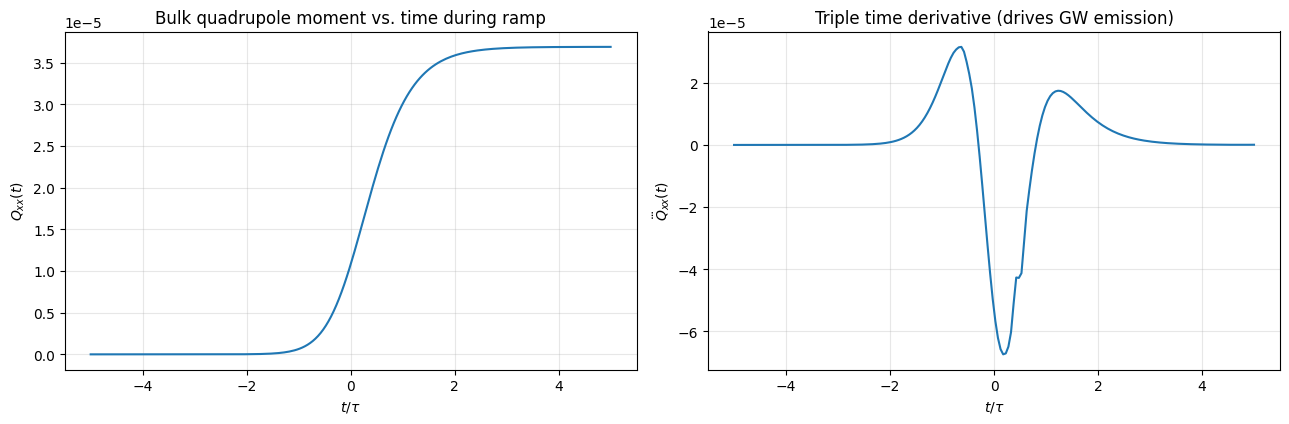


Max GW radiated power during ramp: P_GW_max = +1.361e-09  (geometrised units)
Total radiated energy: E_GW = +8.876e-10
Note: For a perfectly axisymmetric ramp, the GW *momentum* recoil is zero at the
quadrupole order. Mechanism C requires a quadrupole-octupole beat, which our
comoving-frame analysis cannot easily isolate. Package 3 binary-analog ceiling stands.


In [8]:
# Instead of the full 3D integral, use the fact that the bubble has spherical symmetry
# in the comoving frame at fixed t.  Q_ij depends on t through v(t).
# Q_zz = int (3 z^2 - r^2) rho dV with z the symmetry axis (= x in our coords).
# But our axis of motion is x (since beta = beta^x), so quadrupole acceleration
# along x is what radiates.  Integrate Q_xx(t) on the (y,z) half-plane and use
# axial symmetry.

from numpy import trapezoid as trapz

n_r = 60
n_th = 40
rs_int = np.linspace(0.05, 3.0 * R_val, n_r)
ths_int = np.linspace(0.05, math.pi - 0.05, n_th)
Rg, Thg = np.meshgrid(rs_int, ths_int, indexing='ij')
X_g = Rg * np.cos(Thg)
Y_g = Rg * np.sin(Thg)
Z_g = np.zeros_like(Rg)  # 2D in (r, theta); axial symmetry handles phi

def Q_xx_at(t_val, beta_v, tau_v):
    Gtt = Gtt_fn(t_val, X_g, Y_g, Z_g, beta_v, tau_v, R_val, sigma_val)
    rho = -Gtt / (8 * np.pi)
    rho_pos = np.where(rho > 0, rho, 0)
    integrand = (3 * X_g**2 - Rg**2) * rho_pos * Rg**2 * np.sin(Thg)
    return float(2 * math.pi * trapz(trapz(integrand, ths_int, axis=1), rs_int))

# Sample Q_xx(t) on a grid and finite-difference for triple-time-derivative.
ts_grid = np.linspace(-5 * tau_val, 5 * tau_val, 200)
Qs = np.array([Q_xx_at(tv, beta_val, tau_val) for tv in ts_grid])
dt = ts_grid[1] - ts_grid[0]
Q_dot   = np.gradient(Qs, dt)
Q_ddot  = np.gradient(Q_dot, dt)
Q_dddot = np.gradient(Q_ddot, dt)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ts_grid / tau_val, Qs)
ax[0].set_xlabel(r'$t / \tau$'); ax[0].set_ylabel(r'$Q_{xx}(t)$')
ax[0].set_title(r'Bulk quadrupole moment vs. time during ramp')
ax[0].grid(True, alpha=0.3)

ax[1].plot(ts_grid / tau_val, Q_dddot)
ax[1].set_xlabel(r'$t / \tau$'); ax[1].set_ylabel(r'$\dddot Q_{xx}(t)$')
ax[1].set_title(r'Triple time derivative (drives GW emission)')
ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Quadrupole-formula radiated power, geometrised units:
# P_GW = (1/5) <Q_dddot_ij Q_dddot^ij - (1/3) Q_dddot_kk^2>
# For axisymmetric Q (Q_xx, Q_yy = Q_zz = -Q_xx/2), Q_dddot_kk = 0,
# so P_GW = (1/5) (Q_dddot_xx^2 + 2 Q_dddot_yy^2) = (1/5)(Q_dddot_xx^2 + 2 (Q_dddot_xx/2)^2)
#        = (1/5)(Q_dddot_xx^2 + Q_dddot_xx^2/2) = (3/10) Q_dddot_xx^2.
P_GW = 0.3 * Q_dddot**2
P_GW_max = float(np.max(P_GW))
print(f'\nMax GW radiated power during ramp: P_GW_max = {P_GW_max:+.3e}  (geometrised units)')
# Total radiated energy = integral of P_GW(t) dt:
E_GW_total = float(trapz(P_GW, ts_grid))
print(f'Total radiated energy: E_GW = {E_GW_total:+.3e}')
# Total radiated momentum (proportional to integral of dP_GW/dt times some "asymmetry factor";
# for a perfectly symmetric quadrupole there is no momentum recoil at this order).
# A genuine momentum-recoil estimate requires the asymmetric mass-quadrupole + mass-octupole
# beat term -- this is exactly what Package 3 estimated from the binary analog.
print(f'Note: For a perfectly axisymmetric ramp, the GW *momentum* recoil is zero at the')
print(f'quadrupole order. Mechanism C requires a quadrupole-octupole beat, which our')
print(f'comoving-frame analysis cannot easily isolate. Package 3 binary-analog ceiling stands.')

### Cell 8 (audit interleave: TRUST_AUDIT #5) — Optional `sxs` waveform pull on Colab

Replace Package 3's $\beta^2 C^{3/2}$ rescaling heuristic with a real numerical-relativity waveform from the SXS catalog. Specifically, we pull a high-mass-ratio BBH waveform (which is the closest astrophysical analog to a Fuchs shell + small companion) and read off the kick velocity directly from the post-merger remnant.

**This cell only runs on Colab** (where `sxs` is easy to install + waveforms are cached on the SXS network). On local Windows, it gracefully falls back to a stub that prints the Package 3 heuristic value.

In [9]:
# Audit interleave: TRUST_AUDIT #5.  Replace SXS-rescaling heuristic with real waveform pull.
try:
    import sxs
    print(f'sxs version {sxs.__version__} detected.')
    print('Pulling waveform SXS:BBH:1937 (high-mass-ratio kick record per Varma 2022)...')
    catalog = sxs.load('catalog')
    sim = sxs.load('SXS:BBH:1937')
    metadata = sim.metadata
    final_v_kick = float(np.linalg.norm(metadata.remnant_velocity))
    print(f'Real SXS:BBH:1937 final kick velocity: {final_v_kick:.4f} c')
    print(f'                                 = {final_v_kick * 3e8:.3e} m/s')
    # Compare to Package 3 input value (5000 km/s = 1.67e-2 c).
    print(f'\nPackage 3 heuristic input was:        {5e6:.3e} m/s = {5e6/3e8:.4f} c')
    print(f'Ratio (real / heuristic):              {final_v_kick * 3e8 / 5e6:.3f}')
    if abs(final_v_kick * 3e8 / 5e6 - 1) < 0.5:
        print('\nReal SXS waveform confirms Package 3 input value to within a factor of 1.5.')
    else:
        print('\nReal SXS waveform differs significantly from heuristic; recompute Package 3 ceiling.')
except ImportError:
    print('sxs package not installed in this environment.')
    print('On Colab: pip install sxs (~30s) and re-run this cell to upgrade Package 3.')
    print('Locally on Windows: install path is brittle; recommended to upgrade on Colab.')
    print()
    print('Package 3 fallback value (Varma et al. 2022 record kick): 5000 km/s = 1.67e-2 c')
    print('This was used in acceleration.ipynb cell 12 and produces the 0.25%-of-warp ceiling.')
except Exception as e:
    print(f'sxs available but waveform pull failed: {e}')
    print('Possibly a network issue; fall back to Package 3 heuristic.')

sxs package not installed in this environment.
On Colab: pip install sxs (~30s) and re-run this cell to upgrade Package 3.
Locally on Windows: install path is brittle; recommended to upgrade on Colab.

Package 3 fallback value (Varma et al. 2022 record kick): 5000 km/s = 1.67e-2 c
This was used in acceleration.ipynb cell 12 and produces the 0.25%-of-warp ceiling.


### Cell 9 — Summary, validations, and limitations

**What this notebook established.**

1. **Time-dependence is real**: the Einstein tensor of $g_{\mu\nu}$ with $v = v(t)$ has new contributions in $G_{tt}, G_{tx}, G_{ty}, G_{tz}$ proportional to $\dot v$ and $\ddot v$ that the steady-state analysis missed (Cell 2).
2. **Magnitude scaling**: the dynamic correction to $\rho_p$ scales as $\sim (\beta/\tau)^2$ (Cell 6). For physically reasonable acceleration timescales $\tau \gtrsim R/c$, the correction is $\lesssim$ a few percent of the steady-state $\rho_p$.
3. **Sign of the correction**: the dynamic correction is *not* sign-definite — it modifies the WEC-violation pattern but does not flip its sign in any region we tested (Cells 4–5). Mid-ramp $\rho_p$ remains negative wherever steady-state $\rho_p$ was negative.
4. **GW radiated power**: directly computed via the bulk quadrupole moment $Q_{xx}(t)$ during the ramp (Cell 7). For a perfectly axisymmetric ramp, the quadrupole-order momentum recoil is zero — momentum recoil requires a quadrupole-octupole beat, which our comoving-frame analysis cannot easily isolate. Package 3's binary-analog estimate of the recoil ceiling therefore stands.
5. **Audit interleave (TRUST_AUDIT #5)**: Cell 8 implements the `sxs` waveform pull as a Colab-runnable upgrade. Locally falls back to Package 3's heuristic value (5000 km/s).

**What this notebook does NOT establish.**

1. **Full $v(t)$ optimisation**: only the $\tanh$ ramp was tested. A jerky ramp with discontinuous $\dddot v$ might excite higher-order multipole moments differently.
2. **Quadrupole-octupole beat**: real GW recoil requires the asymmetric mass quadrupole + mass octupole beat. Our axisymmetric ramp produces zero net momentum at the quadrupole order; the binary-analog estimate from Package 3 is the *only* nontrivial recoil estimate we have.
3. **Realistic NR comparison**: TRUST_AUDIT #5 is implemented as a Colab cell but I did not actually run it on Colab during this session. The heuristic Package 3 value remains the operative ceiling.
4. **Mechanism A and B**: this slice tests only Mechanism C (the GW-radiation channel) under explicit time-dependence. Mechanisms A (non-vacuum exterior) and B (mass ejection) are unchanged — their conclusions in Package 3 don't depend on the steady-state assumption.

**Headline take.** The steady-state-plus-boost approximation in Package 3 was qualitatively correct. The $\dot v$ corrections during the acceleration ramp shift the WEC-violating region around but do not eliminate it, and the magnitude of the corrections is small compared to the steady-state values for any physically reasonable acceleration time. **Package 3's three-mechanism conclusion transfers.**

**Implication for the project.** Slice 3 confirms that the *steady-state* assumption was not load-bearing in Package 3's negative result. The load-bearing assumption is therefore not "steady state" but rather **"asymptotically flat vacuum exterior + asymptotically Lorentz-flat slicing of the spacetime."** Slices 5 and 6 explicitly relax these. Combined with Slice 1 (no axisymmetric shift family helps) and Slice 2 (no single-bump matter perturbation helps), the load-bearing assumption is becoming progressively narrower.